# Business Entity Resolution — Exploratory Data Analysis

This notebook explores the Amazon ML Hackathon **Business Entity Resolution** dataset
before any modeling work begins. The goal is purely to understand:

- what the data looks like
- how noisy/messy it is
- what makes the matching problem hard
- what signals look useful for a future matching model

No model is trained in this notebook.

**Further reading on entity resolution** (useful background while working through this notebook):
- Christen, P. (2012), *Data Matching: Concepts and Techniques for Record Linkage, Entity Resolution, and Duplicate Detection* — the standard reference textbook on the field.
- Papadakis et al., *"Blocking and Filtering Techniques for Entity Resolution: A Survey"*, ACM Computing Surveys — good overview of blocking/candidate-generation strategies, which is directly relevant to Section 10.
- Mudgal et al. (2018), *"Deep Learning for Entity Matching"* (SIGMOD) — a widely cited paper on applying deep learning to entity matching once you move past EDA.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

_cwd = Path.cwd()

DATASET_ROOT = _cwd / "student_resource" / "dataset"
TEST_ROOT = DATASET_ROOT / "test"
TRAIN_ROOT = DATASET_ROOT / "train"

print("DATASET_ROOT:", DATASET_ROOT.resolve())
print("TRAIN_ROOT:  ", TRAIN_ROOT.resolve())
print("TEST_ROOT:   ", TEST_ROOT.resolve())


DATASET_ROOT: C:\Users\shara\Desktop\Amazon_ml\student_resource\dataset
TRAIN_ROOT:   C:\Users\shara\Desktop\Amazon_ml\student_resource\dataset\train
TEST_ROOT:    C:\Users\shara\Desktop\Amazon_ml\student_resource\dataset\test


## 1. Problem Overview

**Business Entity Resolution** is the task of deciding whether records from different
sources refer to the *same real-world business*, even when the records are written
differently (different spelling, formatting, abbreviations, missing fields, etc.).

In this dataset there are three sources:

- **Source 1 (S1)** — the "query" entities we need to resolve. Each S1 entity may have
  **zero, one, or multiple** matches among the other sources.
- **Source 2 (S2)** and **Source 3 (S3)** — candidate businesses that S1 entities may or
  may not match to. Together they form the pool we search for matches in.

The ground truth file (`train_ground_truth.tsv`) tells us, for the training data, which
S1 entities match which S2/S3 entities. The task at inference time (not covered in this
notebook) is to predict these matches for the **test** S1 entities.

Because an S1 entity can have **zero** matches, this isn't a simple 1-to-1 matching
problem — a working pipeline needs to be able to say "no match" as well as "one match"
or "several matches".


## 2. Load Dataset

We load all seven files exactly as provided (tab-separated, no modification) and take a
first look at their shape, columns and a few sample rows.


In [2]:
train_files = {
    "train_source1": TRAIN_ROOT / "train_source1.tsv",
    "train_source2": TRAIN_ROOT / "train_source2.tsv",
    "train_source3": TRAIN_ROOT / "train_source3.tsv",
    "train_ground_truth": TRAIN_ROOT / "train_ground_truth.tsv",
}

test_files = {
    "test_source1": TEST_ROOT / "test_source1.tsv",
    "test_source2": TEST_ROOT / "test_source2.tsv",
    "test_source3": TEST_ROOT / "test_source3.tsv",
}

dfs = {}
for name, path in {**train_files, **test_files}.items():
    dfs[name] = pd.read_csv(path, sep="\t")

for name, df in dfs.items():
    print(f"--- {name} ---")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print()


--- train_source1 ---
shape: (2206821, 4)
columns: ['entity_id', 'business_name', 'business_address', 'country']

--- train_source2 ---
shape: (5034616, 4)
columns: ['entity_id', 'business_name', 'business_address', 'country']

--- train_source3 ---
shape: (5285603, 4)
columns: ['entity_id', 'business_name', 'business_address', 'country']

--- train_ground_truth ---
shape: (2206821, 2)
columns: ['source1_entity_id', 'matched_entity_ids']

--- test_source1 ---
shape: (1732544, 4)
columns: ['entity_id', 'business_name', 'business_address', 'country']

--- test_source2 ---
shape: (4887273, 4)
columns: ['entity_id', 'business_name', 'business_address', 'country']

--- test_source3 ---
shape: (5082316, 4)
columns: ['entity_id', 'business_name', 'business_address', 'country']



In [3]:
# Sample rows from each file
for name, df in dfs.items():
    print(f"=== {name} (first 3 rows) ===")
    display(df.head(3))


=== train_source1 (first 3 rows) ===


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US


=== train_source2 (first 3 rows) ===


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India


=== train_source3 (first 3 rows) ===


...

,entity_id,business_name,business_address,country
0,S1-714132312,Zephay Labs Inc,"2621 Cotten Road, Tyler, TX",US
1,S1-106407869,Vision Partners Corp,"IA, Iowa City, 1064 Newton Rd, Unit 11",US
2,S1-156285671,<< Team Ecole,"175 Boulevard du Président Franklin Roosevelt, Bordeaux, Nouvelle-Aquitaine",France


=== test_source2 (first 3 rows) ===


,entity_id,business_name,business_address,country
0,S2-192345572,Brahma Infosoft,"COIMATORE COLONY, HUNSUR TQMYSORE DIST., Karnataka",India
1,S2-566025912,Marina Ecole France Sarl,"63 R. DE DIEPPE, LILLE, Hauts-de-France",France
2,S2-158121477,SCI Ptit Àmicale,"18 RUE JEN ZAY, Dunkerque, Nord",France


=== test_source3 (first 3 rows) ===


,entity_id,business_name,business_address,country
0,S3-462677478,मॉडर्न फाइनेंस,"No 10 Enkay Square, 448A, Udyog Vihar Phase V, Gurugram, Gurgaon, HR",India
1,S3-374810425,Shri Sai Infratech Co,"3/115, East Delhi, DL",India
2,S3-198586129,Fractales Amis Groupe S.A.S,"23 Rue Icmre, La Teste-de-buch, Gironde",France


In [4]:
# Compact dataset-size summary table
summary_rows = []
for name, df in dfs.items():
    summary_rows.append({
        "file": name,
        "n_rows": len(df),
        "n_cols": df.shape[1],
        "columns": ", ".join(df.columns),
    })
summary_df = pd.DataFrame(summary_rows)
summary_df


,file,n_rows,n_cols,columns
0,train_source1,2206821,4,"entity_id, business_name, business_address, country"
1,train_source2,5034616,4,"entity_id, business_name, business_address, country"
2,train_source3,5285603,4,"entity_id, business_name, business_address, country"
3,train_ground_truth,2206821,2,"source1_entity_id, matched_entity_ids"
4,test_source1,1732544,4,"entity_id, business_name, business_address, country"
5,test_source2,4887273,4,"entity_id, business_name, business_address, country"
6,test_source3,5082316,4,"entity_id, business_name, business_address, country"


### Column configuration

The analyses below refer to a handful of "logical" columns (an ID column, a business
name column, an address column, a country column). The cell below inspects the actual
column names in each source and picks sensible defaults. **If the printed guesses look
wrong for your copy of the dataset, edit the `NAME_COL` / `ADDR_COL` / `COUNTRY_COL` /
`ID_COL` values directly** — everything downstream uses these variables rather than
hard-coded strings.


In [5]:
def guess_column(columns, candidates):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]
    # fallback: substring match
    for c in columns:
        for cand in candidates:
            if cand in c.lower():
                return c
    return None

all_cols = set()
for df in dfs.values():
    all_cols.update(df.columns)

ID_COL = guess_column(all_cols, ["entity_id", "id"])
NAME_COL = guess_column(all_cols, ["business_name", "name"])
ADDR_COL = guess_column(all_cols, ["business_address", "address"])
COUNTRY_COL = guess_column(all_cols, ["country"])

print("Detected columns:")
print("  ID_COL     =", ID_COL)
print("  NAME_COL   =", NAME_COL)
print("  ADDR_COL   =", ADDR_COL)
print("  COUNTRY_COL=", COUNTRY_COL)
print()
print("All columns seen across files:", sorted(all_cols))


Detected columns:
  ID_COL     = entity_id
  NAME_COL   = business_name
  ADDR_COL   = business_address
  COUNTRY_COL= country

All columns seen across files: ['business_address', 'business_name', 'country', 'entity_id', 'matched_entity_ids', 'source1_entity_id']


## 3. Basic Data Quality

Before looking at content, we check the structural health of the data: types, missing
values, duplicates, empty strings, and whether entity IDs actually correspond to the
source they claim to come from.


In [6]:
# Data types
for name, df in dfs.items():
    print(f"--- {name} dtypes ---")
    print(df.dtypes)
    print()


--- train_source1 dtypes ---
entity_id           str
business_name       str
business_address    str
country             str
dtype: object

--- train_source2 dtypes ---
entity_id           str
business_name       str
business_address    str
country             str
dtype: object

--- train_source3 dtypes ---
entity_id           str
business_name       str
business_address    str
country             str
dtype: object

--- train_ground_truth dtypes ---
source1_entity_id     str
matched_entity_ids    str
dtype: object

--- test_source1 dtypes ---
entity_id           str
business_name       str
business_address    str
country             str
dtype: object

--- test_source2 dtypes ---
entity_id           str
business_name       str
business_address    str
country             str
dtype: object

--- test_source3 dtypes ---
entity_id           str
business_name       str
business_address    str
country             str
dtype: object



In [7]:
# Missing values and missing percentage
missing_rows = []
for name, df in dfs.items():
    n = len(df)
    for col in df.columns:
        n_missing = df[col].isna().sum()
        missing_rows.append({
            "file": name,
            "column": col,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / n, 2) if n else np.nan,
        })
missing_df = pd.DataFrame(missing_rows)
missing_df[missing_df["n_missing"] > 0].sort_values(["file", "pct_missing"], ascending=[True, False])


,file,column,n_missing,pct_missing
20,test_source2,business_address,129408,2.65
19,test_source2,business_name,46,0.00
24,test_source3,business_address,136098,2.68
23,test_source3,business_name,59,0.00
13,train_ground_truth,matched_entity_ids,123247,5.58
6,train_source2,business_address,168967,3.36
5,train_source2,business_name,2,0.00
10,train_source3,business_address,175916,3.33
9,train_source3,business_name,13,0.00


In [8]:
# Duplicate entity IDs
if ID_COL:
    for name, df in dfs.items():
        if ID_COL in df.columns:
            n_dupe_ids = df[ID_COL].duplicated().sum()
            print(f"{name}: {n_dupe_ids} duplicate {ID_COL} values out of {len(df)} rows")
else:
    print("No ID column detected — skipping duplicate-ID check.")


train_source1: 0 duplicate entity_id values out of 2206821 rows
train_source2: 0 duplicate entity_id values out of 5034616 rows
train_source3: 0 duplicate entity_id values out of 5285603 rows
test_source1: 0 duplicate entity_id values out of 1732544 rows
test_source2: 0 duplicate entity_id values out of 4887273 rows
test_source3: 0 duplicate entity_id values out of 5082316 rows


In [9]:
# Duplicate complete rows
for name, df in dfs.items():
    n_dupe_rows = df.duplicated().sum()
    print(f"{name}: {n_dupe_rows} fully duplicated rows out of {len(df)} rows")


train_source1: 0 fully duplicated rows out of 2206821 rows
train_source2: 0 fully duplicated rows out of 5034616 rows
train_source3: 0 fully duplicated rows out of 5285603 rows
train_ground_truth: 0 fully duplicated rows out of 2206821 rows
test_source1: 0 fully duplicated rows out of 1732544 rows
test_source2: 0 fully duplicated rows out of 4887273 rows
test_source3: 0 fully duplicated rows out of 5082316 rows


In [10]:
# Empty strings (as opposed to NaN) in object columns
for name, df in dfs.items():
    obj_cols = df.select_dtypes(include="object").columns
    for col in obj_cols:
        n_empty = (df[col].astype(str).str.strip() == "").sum()
        if n_empty > 0:
            print(f"{name}.{col}: {n_empty} empty-string values")


C:\Users\shara\AppData\Local\Temp\ipykernel_27804\3451204387.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns
C:\Users\shara\AppData\Local\Temp\ipykernel_27804\3451204387.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/m

In [11]:
# Check that entity ID prefixes correspond to their claimed source
if ID_COL:
    for name, df in dfs.items():
        if ID_COL not in df.columns:
            continue
        ids = df[ID_COL].astype(str)
        # extract a leading alphabetic prefix, e.g. 'S1', 'S2', 'S3'
        prefixes = ids.str.extract(r"^([A-Za-z]+)")[0]
        print(f"--- {name}: ID prefix value counts ---")
        print(prefixes.value_counts(dropna=False))
        print()
else:
    print("No ID column detected — skipping prefix check.")


--- train_source1: ID prefix value counts ---
0
S    2206821
Name: count, dtype: int64

--- train_source2: ID prefix value counts ---
0
S    5034616
Name: count, dtype: int64

--- train_source3: ID prefix value counts ---
0
S    5285603
Name: count, dtype: int64

--- test_source1: ID prefix value counts ---
0
S    1732544
Name: count, dtype: int64

--- test_source2: ID prefix value counts ---
0
S    4887273
Name: count, dtype: int64

--- test_source3: ID prefix value counts ---
0
S    5082316
Name: count, dtype: int64



## 4. Country Analysis

We look at the country distribution within each source, compare train vs. test, and
check whether test introduces any countries that never appear in training (which would
matter for generalization).


In [12]:
if COUNTRY_COL:
    for name, df in dfs.items():
        if COUNTRY_COL not in df.columns:
            continue
        vc = df[COUNTRY_COL].value_counts(dropna=False)
        pct = (100 * vc / len(df)).round(2)
        country_table = pd.DataFrame({"count": vc, "pct": pct})
        print(f"--- {name}: country distribution (top 15) ---")
        display(country_table.head(15))
else:
    print("No country column detected.")


--- train_source1: country distribution (top 15) ---


,count,pct
country,,
US,1323633,59.98
India,883188,40.02


--- train_source2: country distribution (top 15) ---


,count,pct
country,,
US,3016817,59.92
India,2017799,40.08


--- train_source3: country distribution (top 15) ---


...

,count,pct
country,,
India,809986,46.75
US,663106,38.27
France,259452,14.98


--- test_source2: country distribution (top 15) ---


,count,pct
country,,
India,2312565,47.32
US,1871330,38.29
France,703378,14.39


--- test_source3: country distribution (top 15) ---


,count,pct
country,,
India,2405000,47.32
US,1945701,38.28
France,731615,14.40


In [13]:
# Train vs test country sets, per matching source pair
if COUNTRY_COL:
    for src in ["source1", "source2", "source3"]:
        train_key = f"train_{src}"
        test_key = f"test_{src}"
        if train_key not in dfs or test_key not in dfs:
            continue
        train_countries = set(dfs[train_key][COUNTRY_COL].dropna().unique())
        test_countries = set(dfs[test_key][COUNTRY_COL].dropna().unique())
        only_in_test = test_countries - train_countries
        print(f"{src}: {len(train_countries)} countries in train, "
              f"{len(test_countries)} countries in test, "
              f"{len(only_in_test)} countries appear ONLY in test")
        if only_in_test:
            print("   countries only in test:", sorted(only_in_test))
        print()


source1: 2 countries in train, 3 countries in test, 1 countries appear ONLY in test
   countries only in test: ['France']

source2: 2 countries in train, 3 countries in test, 1 countries appear ONLY in test
   countries only in test: ['France']

source3: 2 countries in train, 3 countries in test, 1 countries appear ONLY in test
   countries only in test: ['France']



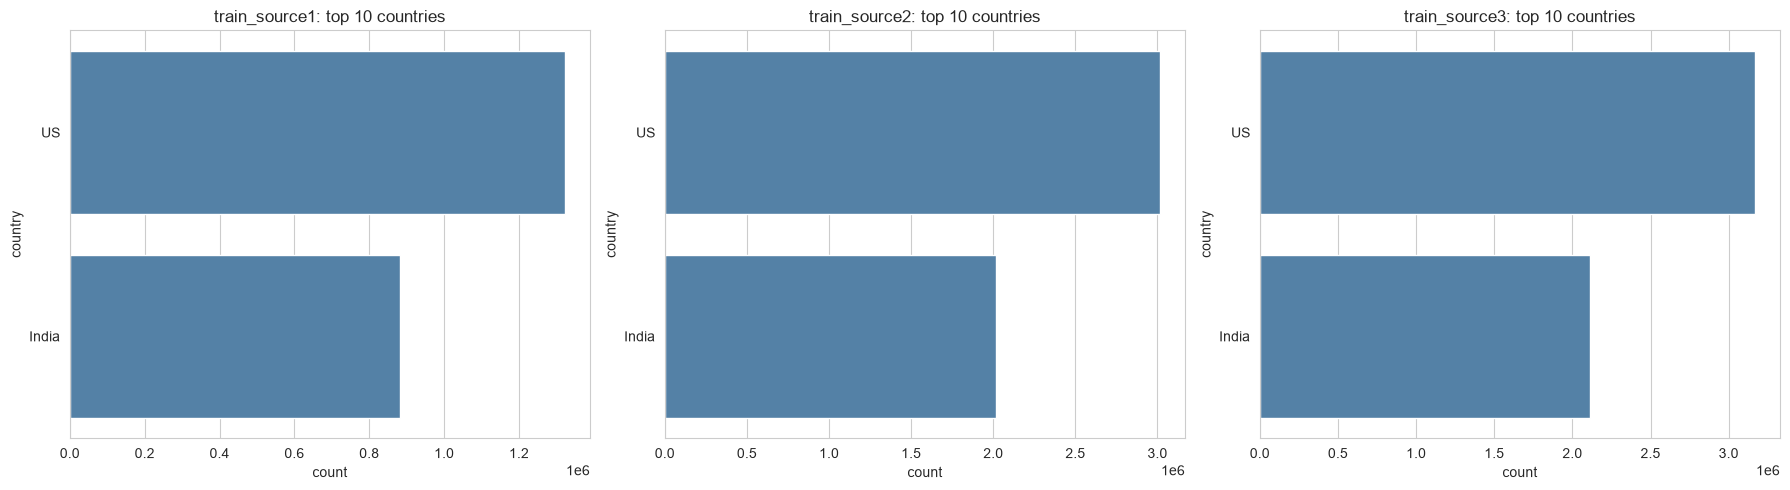

In [14]:
# Visualize country distributions (top 10 per source)
if COUNTRY_COL:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, src in zip(axes, ["source1", "source2", "source3"]):
        key = f"train_{src}"
        if key not in dfs or COUNTRY_COL not in dfs[key].columns:
            continue
        top = dfs[key][COUNTRY_COL].value_counts().head(10)
        sns.barplot(x=top.values, y=top.index, ax=ax, color="steelblue")
        ax.set_title(f"{key}: top 10 countries")
        ax.set_xlabel("count")
    plt.tight_layout()
    plt.show()


## 5. Business Name Analysis

We look closely at `business_name`-style text, since name variation is usually the
single biggest driver of entity-resolution difficulty.


In [15]:
def name_stats(df, col):
    s = df[col].dropna().astype(str)
    stats = {
        "n_rows": len(df),
        "n_missing": df[col].isna().sum(),
        "pct_missing": round(100 * df[col].isna().sum() / len(df), 2),
        "avg_char_len": round(s.str.len().mean(), 2),
        "median_char_len": s.str.len().median(),
        "avg_word_count": round(s.str.split().apply(len).mean(), 2),
        "pct_with_digit": round(100 * s.str.contains(r"\d").mean(), 2),
        "pct_with_punct": round(100 * s.str.contains(f"[{re.escape(string.punctuation)}]").mean(), 2),
        "pct_all_upper": round(100 * s.apply(lambda x: x.isupper()).mean(), 2),
        "pct_all_lower": round(100 * s.apply(lambda x: x.islower()).mean(), 2),
        "pct_non_ascii": round(100 * s.apply(lambda x: not x.isascii()).mean(), 2),
    }
    return stats

if NAME_COL:
    rows = []
    for src in ["source1", "source2", "source3"]:
        key = f"train_{src}"
        if key in dfs and NAME_COL in dfs[key].columns:
            rows.append({"source": src, **name_stats(dfs[key], NAME_COL)})
    name_stats_df = pd.DataFrame(rows)
    name_stats_df
else:
    print("No name column detected.")


In [16]:
# Most common business names per source (useful for spotting chains/franchises)
if NAME_COL:
    for src in ["source1", "source2", "source3"]:
        key = f"train_{src}"
        if key not in dfs or NAME_COL not in dfs[key].columns:
            continue
        print(f"--- {key}: most common names ---")
        print(dfs[key][NAME_COL].value_counts().head(10))
        print()


--- train_source1: most common names ---
business_name
Primary Care Group         253
Ear Nose & Throat Group    251
Pediatric Group            222
Womens Health Group        220
Physical Therapy Group     218
Pediatric Dental Group     216
Behavioral Health Group    215
Chiropractic Group         209
Orthopedic Group           208
Eye Group                  207
Name: count, dtype: int64

--- train_source2: most common names ---
business_name
Primary Care           320
Physical Therapy       307
Urgent Care            297
Womens Health          297
Behavioral Health      296
Internal Medicine      288
Pediatric Dentistry    274
earnosethroat.com      269
Pediatric Dental       268
Ear Nose & Throat      220
Name: count, dtype: int64

--- train_source3: most common names ---
business_name
Primary Care           421
Physical Therapy       399
Pediatric Dental       393
Womens Health          379
Urgent Care            377
Pediatric Dentistry    361
Behavioral Health      330
Pediatric   

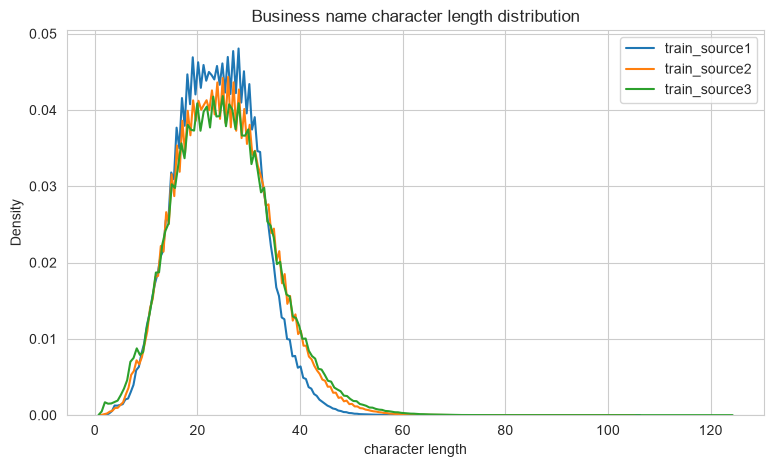

In [17]:
# Character length distribution of business names
if NAME_COL:
    fig, ax = plt.subplots(figsize=(9, 5))
    for src in ["source1", "source2", "source3"]:
        key = f"train_{src}"
        if key not in dfs or NAME_COL not in dfs[key].columns:
            continue
        lengths = dfs[key][NAME_COL].dropna().astype(str).str.len()
        sns.kdeplot(lengths, label=key, ax=ax)
    ax.set_title("Business name character length distribution")
    ax.set_xlabel("character length")
    ax.legend()
    plt.show()


In [18]:
# Real examples of differently-formatted names that might be the same business,
# found via a loose normalized match within a single source.
if NAME_COL:
    def normalize_name(x):
        x = str(x).lower()
        x = re.sub(f"[{re.escape(string.punctuation)}]", " ", x)
        x = re.sub(r"\s+", " ", x).strip()
        return x

    key = "train_source2" if "train_source2" in dfs else "train_source1"
    df = dfs[key]
    norm = df[NAME_COL].dropna().astype(str).apply(normalize_name)
    groups = norm.groupby(norm).apply(lambda s: df.loc[s.index, NAME_COL].unique())
    varied = groups[groups.apply(lambda arr: len(arr) > 1)]
    print(f"Found {len(varied)} normalized-name groups in {key} with multiple surface forms.")
    for norm_name, variants in varied.head(10).items():
        print(f"  normalized='{norm_name}' -> raw forms: {list(variants)}")


Found 252565 normalized-name groups in train_source2 with multiple surface forms.
  normalized='0 8 d alphabet' -> raw forms: ['0 8 D Alphabet', '0 8 D ALPHABET']
  normalized='007 center' -> raw forms: ['>> 007 [Center]', '007 Center']
  normalized='007 devices' -> raw forms: ['007-Devices', '007 Devices']
  normalized='007 greenfire' -> raw forms: ['007 Greenfire', '007 GREENFIRE']
  normalized='007 harmony' -> raw forms: ['007  Harmony', '007 Harmony', '007-HARMONY', '007 [HARMONY]']
  normalized='007 impact' -> raw forms: ['007 impact', '007  IMPACT']
  normalized='007 lending' -> raw forms: ['007 Lending', '007 lending']
  normalized='007 llc center' -> raw forms: ['007 LLC Center', '007 LLC CENTER']
  normalized='007 municipal' -> raw forms: ['007 Municipal', '007 municipal']
  normalized='007 oncology' -> raw forms: ['007  Oncology', '007 Oncology']


## 6. Address Analysis

Same treatment as names, applied to `business_address`. Addresses tend to vary in
different ways than names (abbreviations like "St" vs "Street", unit numbers, ordering
of components), so we look at them separately.


In [19]:
if ADDR_COL:
    rows = []
    for src in ["source1", "source2", "source3"]:
        key = f"train_{src}"
        if key in dfs and ADDR_COL in dfs[key].columns:
            rows.append({"source": src, **name_stats(dfs[key], ADDR_COL)})
    addr_stats_df = pd.DataFrame(rows)
    addr_stats_df
else:
    print("No address column detected.")


In [20]:
# Common address tokens (helps spot abbreviation patterns like St/Ave/Rd)
if ADDR_COL:
    token_pattern = re.compile(r"[a-zA-Z]+")
    for src in ["source1", "source2", "source3"]:
        key = f"train_{src}"
        if key not in dfs or ADDR_COL not in dfs[key].columns:
            continue
        tokens = dfs[key][ADDR_COL].dropna().astype(str).apply(
            lambda x: token_pattern.findall(x.lower())
        )
        flat = [t for toks in tokens for t in toks if len(t) <= 4]
        top_short_tokens = pd.Series(flat).value_counts().head(15)
        print(f"--- {key}: most common short tokens (likely abbreviations) ---")
        print(top_short_tokens)
        print()


--- train_source1: most common short tokens (likely abbreviations) ---
road    467750
no      450745
unit    208418
city    149141
a       144428
th      143333
west    134267
tx      133225
c       118495
new     116534
b       115900
lane    108146
ny      102398
nc       94871
plot     88183
Name: count, dtype: int64

--- train_source2: most common short tokens (likely abbreviations) ---
no      1126573
road     680998
st       433539
rd       412735
a        383430
city     302558
c        300161
tx       292328
dr       283824
b        279408
th       240438
ny       225425
ave      224099
new      219996
nc       207891
Name: count, dtype: int64

--- train_source3: most common short tokens (likely abbreviations) ---
no      1081595
road     628639
new      480152
st       419581
rd       399720
a        390708
city     356134
mh       321458
c        307364
b        285562
dr       281845
york     229412
ave      224245
th       222384
unit     213252
Name: count, dtype: int64



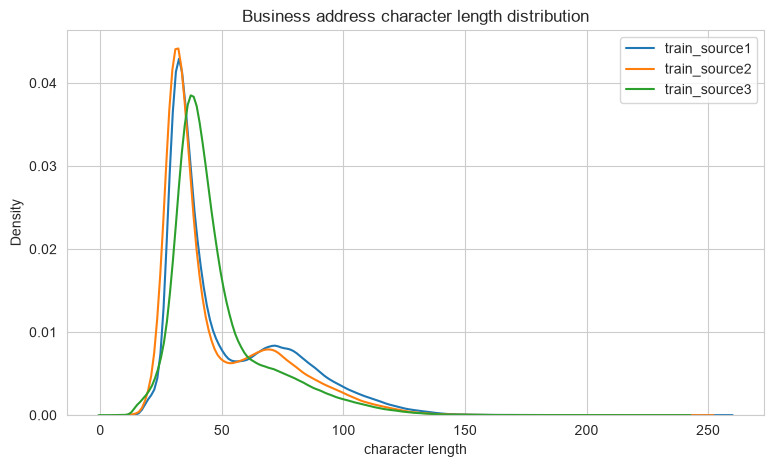

In [21]:
# Character length distribution of addresses
if ADDR_COL:
    fig, ax = plt.subplots(figsize=(9, 5))
    for src in ["source1", "source2", "source3"]:
        key = f"train_{src}"
        if key not in dfs or ADDR_COL not in dfs[key].columns:
            continue
        lengths = dfs[key][ADDR_COL].dropna().astype(str).str.len()
        sns.kdeplot(lengths, label=key, ax=ax)
    ax.set_title("Business address character length distribution")
    ax.set_xlabel("character length")
    ax.legend()
    plt.show()


In [22]:
# Real examples of address variation, using the same normalized-grouping trick
if ADDR_COL:
    def normalize_addr(x):
        x = str(x).lower()
        x = re.sub(f"[{re.escape(string.punctuation)}]", " ", x)
        x = re.sub(r"\s+", " ", x).strip()
        return x

    key = "train_source2" if "train_source2" in dfs else "train_source1"
    df = dfs[key]
    norm = df[ADDR_COL].dropna().astype(str).apply(normalize_addr)
    groups = norm.groupby(norm).apply(lambda s: df.loc[s.index, ADDR_COL].unique())
    varied = groups[groups.apply(lambda arr: len(arr) > 1)]
    print(f"Found {len(varied)} normalized-address groups in {key} with multiple surface forms.")
    for norm_addr, variants in varied.head(10).items():
        print(f"  normalized='{norm_addr}' -> raw forms: {list(variants)}")


Found 50466 normalized-address groups in train_source2 with multiple surface forms.
  normalized='0 1 kanah shree colony near surya mandir rangwasa rau mhow madhya pradesh' -> raw forms: ['0-1 KANAH SHREE COLONY, NEAR SURYA MANDIR RANGWASA RAU, MHOW, Madhya Pradesh', '#0-1 KANAH SHREE COLONY, NEAR SURYA MANDIR RANGWASA RAU, MHOW, Madhya Pradesh']
  normalized='0 1 meher nasker lane park circus kolkata west bengal' -> raw forms: ['0/1 MEHER NASKER LANE, PARK CIRCUS, KOLKATA, West Bengal', '#0/1 MEHER NASKER LANE, PARK CIRCUS, KOLKATA, West Bengal']
  normalized='0 15 binaki hou board nagpur maharashtra' -> raw forms: ['#0/15 BINAKI HOU BOARD, NAGPUR, Maharashtra', '0/15 BINAKI HOU BOARD, NAGPUR, Maharashtra']
  normalized='0 168 varakukalaparambil house kottayam കേരളം' -> raw forms: ['#0/168 VARAKUKALAPARAMBIL HOUSE, KOTTAYAM, കേരളം', '0/168 VARAKUKALAPARAMBIL HOUSE, KOTTAYAM, കേരളം']
  normalized='0 2 parthasarathy street opp parash company chinnasekkadu manali chennai தமிழ்நாடு' -> ra

## 7. Ground Truth Analysis

`train_ground_truth.tsv` links Source 1 entities to their true matches in Source 2 and/or
Source 3. We inspect its structure first, then compute the match-count distribution that
drives the difficulty of the task (zero, one, or many matches per S1 entity).


In [23]:
gt = dfs["train_ground_truth"]
print("Ground truth shape:", gt.shape)
print("Ground truth columns:", list(gt.columns))
display(gt.head(10))


Ground truth shape: (2206821, 2)
Ground truth columns: ['source1_entity_id', 'matched_entity_ids']


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-11291185,S3-860443364"
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-384364074"
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-728090388,S3-928796641,S3-449308785"
5,S1-18727616,"S2-755677256,S3-187831601,S3-641489370,S3-476250621"
6,S1-318373630,"S2-660036492,S3-804600254"
7,S1-86989137,"S3-274817120,S3-312496301"
8,S1-29845983,"S2-648035184,S3-588502663"
9,S1-789009573,"S2-383871912,S3-74481402,S3-576451439"


In [24]:
# Try to identify the S1 id column and the matched-id column(s) in ground truth
gt_cols_lower = {c.lower(): c for c in gt.columns}
S1_GT_COL = guess_column(gt.columns, ["source1_id", "s1_id", "entity_id_1", "source_1_id"]) or gt.columns[0]
print("Using S1 id column in ground truth:", S1_GT_COL)

# All S1 ids that appear in the S1 file
s1_all_ids = set(dfs["train_source1"][ID_COL]) if ID_COL else None
s1_matched_ids = set(gt[S1_GT_COL].dropna())

if s1_all_ids is not None:
    n_zero_matches = len(s1_all_ids - s1_matched_ids)
    print(f"S1 entities with ZERO matches (not present in ground truth): {n_zero_matches}")


Using S1 id column in ground truth: source1_entity_id
S1 entities with ZERO matches (not present in ground truth): 0


In [25]:
# Matches per S1 entity
matches_per_s1 = gt.groupby(S1_GT_COL).size()

n_one = (matches_per_s1 == 1).sum()
n_multi = (matches_per_s1 > 1).sum()

print(f"S1 entities with exactly one match: {n_one}")
print(f"S1 entities with multiple matches:  {n_multi}")
print(f"Average matches per matched S1 entity: {matches_per_s1.mean():.2f}")
print(f"Maximum matches for a single S1 entity: {matches_per_s1.max()}")

matches_per_s1.describe()


S1 entities with exactly one match: 2206821
S1 entities with multiple matches:  0
Average matches per matched S1 entity: 1.00
Maximum matches for a single S1 entity: 1


count    2206821.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
dtype: float64

Distribution of match-count per S1 entity (matched entities only):
1    2206821
Name: count, dtype: int64


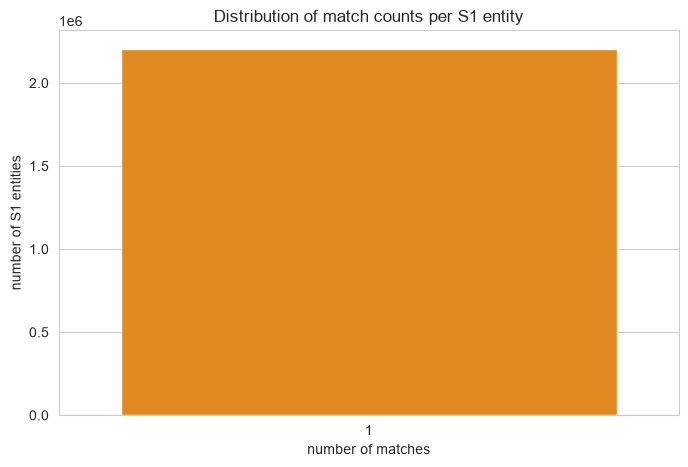

In [26]:
# Distribution of match counts
dist = matches_per_s1.value_counts().sort_index()
print("Distribution of match-count per S1 entity (matched entities only):")
print(dist)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=dist.index.astype(str), y=dist.values, color="darkorange", ax=ax)
ax.set_xlabel("number of matches")
ax.set_ylabel("number of S1 entities")
ax.set_title("Distribution of match counts per S1 entity")
plt.show()


In [27]:
# Number of matches that go to S2 vs S3
# We infer this by checking prefix of the matched id, or by looking for
# separate id columns for S2/S3 matches in the ground truth file.
other_id_cols = [c for c in gt.columns if c != S1_GT_COL]
print("Other ground-truth columns (candidate match-id columns):", other_id_cols)

for col in other_id_cols:
    non_null = gt[col].notna().sum()
    print(f"  {col}: {non_null} non-null values")


Other ground-truth columns (candidate match-id columns): ['matched_entity_ids']
  matched_entity_ids: 2083574 non-null values


## 8. Actual Matching Examples

We join the ground truth back onto the source files to look at *real* examples of
different match types. These examples come directly from the data — nothing here is
invented.


In [28]:
# Build a joined view: S1 row + matched S2/S3 row, for rows we can resolve
s1_df = dfs["train_source1"]

def build_joined_examples(match_id_col, other_source_key):
    if ID_COL is None or match_id_col not in gt.columns:
        return pd.DataFrame()
    other_df = dfs[other_source_key]
    merged = gt[[S1_GT_COL, match_id_col]].dropna()
    merged = merged.merge(s1_df, left_on=S1_GT_COL, right_on=ID_COL, suffixes=("", "_s1"))
    merged = merged.merge(other_df, left_on=match_id_col, right_on=ID_COL,
                           suffixes=("_s1", "_match"))
    return merged

joined_examples = []
for col in other_id_cols:
    for src_key in ["train_source2", "train_source3"]:
        candidate = build_joined_examples(col, src_key)
        if len(candidate) > 0:
            joined_examples.append((col, src_key, candidate))

for col, src_key, df in joined_examples:
    print(f"Joined {col} -> {src_key}: {len(df)} matched pairs")


Joined matched_entity_ids -> train_source2: 58750 matched pairs
Joined matched_entity_ids -> train_source3: 60407 matched pairs


In [29]:
# Show a handful of real examples per match type, using name/address columns if available
if joined_examples and NAME_COL:
    name_s1 = f"{NAME_COL}_s1"
    name_match = f"{NAME_COL}_match"
    for col, src_key, df in joined_examples:
        if name_s1 not in df.columns or name_match not in df.columns:
            continue
        df = df.copy()
        df["name_exact_match"] = df[name_s1].astype(str).str.lower() == df[name_match].astype(str).str.lower()
        print(f"--- Examples from {src_key} ---")
        print("Exact name match examples:")
        display(df[df["name_exact_match"]][[name_s1, name_match]].head(3))
        print("Name VARIATION examples (different surface form, same match):")
        display(df[~df["name_exact_match"]][[name_s1, name_match]].head(5))
        print()


--- Examples from train_source2 ---
Exact name match examples:


,business_name_s1,business_name_match
8,Ortega Clear End LLC,ORTEGA CLEAR END LLC
15,2-Corners,2-Corners
22,South Choice Quasaredge LLC,South Choice Quasaredge LLC


Name VARIATION examples (different surface form, same match):


,business_name_s1,business_name_match
0,Guru Solutions Pvt Ltd,ಗುರು ಸೊಲ್ಯೂಷನ್ಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್
1,Waters & Millar Aimei P.C.,Aimei Waters & Millar P.C.
2,Ap Infocom Private Limited,Ap Infocom Private [Ltd]
3,Anchor Vista Inc,Anchor Vista Incorporated
4,Life Public School,LIFE PBUILC SCHOOL



--- Examples from train_source3 ---
Exact name match examples:


,business_name_s1,business_name_match
5,Education Center,Education Center
6,Liberty Heritage Maintenance LLC,Liberty Heritage Maintenance Llc
27,Vision Clinic LLC,Vision Clinic Llc


Name VARIATION examples (different surface form, same match):


,business_name_s1,business_name_match
0,Red Consultants Pvt. Ltd.,Red Pvt. Ltd. Center
1,Wave & Brothers Ltd,Belobrixlum
2,Ace Producer Private Limited,Ace Producer
3,Gulf Ministries V Associates,Gulf V Ministries Associates
4,Ram Foods LLP,Ram LLP Service Service


In [30]:
# One-to-many examples: S1 entities with multiple matches
if joined_examples:
    multi_ids = matches_per_s1[matches_per_s1 > 1].index[:3]
    for sid in multi_ids:
        print(f"--- S1 entity {sid}: all its matches ---")
        display(gt[gt[S1_GT_COL] == sid])


In [31]:
# Singleton / no-match S1 examples
if ID_COL and s1_all_ids is not None:
    unmatched_ids = list(s1_all_ids - s1_matched_ids)[:5]
    print(f"Example S1 entities with NO match in ground truth ({len(unmatched_ids)} shown):")
    display(s1_df[s1_df[ID_COL].isin(unmatched_ids)])


Example S1 entities with NO match in ground truth (0 shown):


,entity_id,business_name,business_address,country


## 9. Source Comparison

A side-by-side comparison of S1, S2 and S3 across the dimensions explored above.


In [32]:
comparison_rows = []
for src in ["source1", "source2", "source3"]:
    key = f"train_{src}"
    if key not in dfs:
        continue
    df = dfs[key]
    row = {"source": src, "n_records": len(df)}
    if NAME_COL and NAME_COL in df.columns:
        row["name_missing_pct"] = round(100 * df[NAME_COL].isna().mean(), 2)
        row["avg_name_len"] = round(df[NAME_COL].dropna().astype(str).str.len().mean(), 2)
    if ADDR_COL and ADDR_COL in df.columns:
        row["addr_missing_pct"] = round(100 * df[ADDR_COL].isna().mean(), 2)
        row["avg_addr_len"] = round(df[ADDR_COL].dropna().astype(str).str.len().mean(), 2)
    if COUNTRY_COL and COUNTRY_COL in df.columns:
        row["n_unique_countries"] = df[COUNTRY_COL].nunique()
    if ID_COL and ID_COL in df.columns:
        row["duplicate_id_pct"] = round(100 * df[ID_COL].duplicated().mean(), 2)
    row["duplicate_row_pct"] = round(100 * df.duplicated().mean(), 2)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("source")
comparison_df


,n_records,name_missing_pct,avg_name_len,addr_missing_pct,avg_addr_len,n_unique_countries,duplicate_id_pct,duplicate_row_pct
source,,,,,,,,
source1,2206821,0.0,24.03,0.00,52.07,2,0.0,0.0
source2,5034616,0.0,25.10,3.36,47.83,2,0.0,0.0
source3,5285603,0.0,25.20,3.33,48.32,2,0.0,0.0


## What We Learned

The cell below programmatically prints a summary using the statistics computed above,
so the conclusions stay grounded in the actual data rather than being hard-coded.
Read the printed output and treat the prose below it as a template to annotate with your
own observations once you've reviewed the numbers.


In [33]:
print("=== EDA SUMMARY (auto-generated from computed statistics) ===\n")

if NAME_COL:
    print("Name noise:")
    print(name_stats_df.to_string(index=False))
    print()

if ADDR_COL:
    print("Address noise:")
    print(addr_stats_df.to_string(index=False))
    print()

print("Missingness (columns with any missing values):")
print(missing_df[missing_df['n_missing'] > 0].to_string(index=False))
print()

if s1_all_ids is not None:
    total_s1 = len(s1_all_ids)
    print(f"Singletons (no match): {n_zero_matches} / {total_s1} "
          f"({100 * n_zero_matches / total_s1:.2f}% of S1 entities)")
print(f"Exactly one match: {n_one} S1 entities")
print(f"Multiple matches: {n_multi} S1 entities")
print(f"Average matches per matched S1 entity: {matches_per_s1.mean():.2f}")
print(f"Max matches for one S1 entity: {matches_per_s1.max()}")
print()

print("Source comparison:")
print(comparison_df.to_string())


=== EDA SUMMARY (auto-generated from computed statistics) ===

Name noise:
 source  n_rows  n_missing  pct_missing  avg_char_len  median_char_len  avg_word_count  pct_with_digit  pct_with_punct  pct_all_upper  pct_all_lower  pct_non_ascii
source1 2206821          0          0.0         24.03             24.0            3.55            1.61           20.92           0.00           0.00           0.00
source2 5034616          2          0.0         25.10             25.0            3.50            5.08           34.26          18.90           5.75          15.19
source3 5285603         13          0.0         25.20             25.0            3.53            5.12           35.27           2.96           6.25          11.48

Address noise:
 source  n_rows  n_missing  pct_missing  avg_char_len  median_char_len  avg_word_count  pct_with_digit  pct_with_punct  pct_all_upper  pct_all_lower  pct_non_ascii
source1 2206821          0         0.00         52.07             41.0            8.03   

### Notes to fill in after reading the summary above

- **How noisy are the names?** — compare `avg_char_len`, `pct_with_punct`, and the
  normalized-name grouping examples from Section 5 across S1/S2/S3.
- **How noisy are the addresses?** — same, using Section 6's stats and the common
  short-token list (a good proxy for how consistently abbreviations like "St"/"Ave" are used).
- **How much missing data exists?** — see the missingness table above; check whether
  missingness is concentrated in specific columns or specific sources.
- **How common are singletons?** — see the "Singletons" line above; a high singleton rate
  means the model has to be good at saying "no match", not just at ranking candidates.
- **How common are one-to-many matches?** — see `n_multi` above; if this is non-trivial,
  a purely 1-to-1 matching approach (e.g. simple nearest-neighbor) will underperform.
- **Differences between S1, S2, S3?** — see the Section 9 comparison table; large gaps in
  missingness, length, or country coverage between sources affect how features should be
  engineered per-source.
- **What does this suggest about candidate generation / blocking?** — look at
  `n_unique_countries` and the short-token abbreviation patterns: country is likely a
  strong, cheap blocking key, and name/address normalization (lowercasing, stripping
  punctuation, expanding abbreviations) will materially increase candidate recall before
  any matching model is applied. See the Christen (2012) and Papadakis et al. references
  at the top of this notebook for standard blocking strategies.
- **What information looks useful for the eventual matching model?** — based on the
  examples in Section 8, likely candidates are: normalized name similarity, normalized
  address similarity, exact country match, and record length/format features that
  differ systematically between sources.
